# TAHAP 1 : Load Dataset
Impor library yang diperlukan

Baca file dataset_tugas1_preprocessing.csv ke dalam DataFrame

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('/content/dataset_tugas1_preprocessing.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB


# Tahap 2: Eksplorasi Awal (EDA)
• Cek struktur dan tipe data

• Tampilkan jumlah nilai hilang per kolom

• Sajikan statistik deskriptif

In [14]:
df_original = df.copy() #saya mengkopi karena dalam proses belajar, sering datanya ter-edit tanpa sengaja
df.info()
print("Data duplikasi ada", df_clean.duplicated().sum(), "buah")
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB
Data duplikasi ada 0 buah
           ID Nama Jenis_Kelamin            Prodi Status Nilai_Akhir  \
count      99   99            99               99     99          70   
unique     99   10             2                4      4           5   
top     MH001  Eka     Laki-laki  Teknik Komputer   Cuti           C   
freq        1   15            50               28     29          17   
mean      NaN  NaN  

# Tahap 3: Menangani Missing Values

• Imputasi nilai kosong pada kolom Nilai_Akhir dan Umur dengan metode yang sesuai

In [25]:
df_clean = df.dropna(subset=['Nilai_Akhir']).copy()
df_clean['Umur'] = df_clean['Umur'].fillna(df_clean['Umur'].median())
df_clean['Umur'] = df_clean['Umur'].astype(int)
df_clean.info()
print(df_clean.describe(include='all'))
df = df_clean.copy() #saya ganti menjadi df lagi agar memudahkan pengetikan.

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 1 to 97
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             70 non-null     object
 1   Nama           70 non-null     object
 2   Jenis_Kelamin  70 non-null     object
 3   Prodi          70 non-null     object
 4   Status         70 non-null     object
 5   Nilai_Akhir    70 non-null     object
 6   Tanggal_Ujian  70 non-null     object
 7   Umur           70 non-null     int64 
dtypes: int64(1), object(7)
memory usage: 4.9+ KB
           ID Nama Jenis_Kelamin        Prodi Status Nilai_Akhir  \
count      70   70            70           70     70          70   
unique     70   10             2            4      4           5   
top     MH002  Eka     Perempuan  Informatika  Aktif           C   
freq        1   10            36           20     20          17   
mean      NaN  NaN           NaN          NaN    NaN         NaN   
std       NaN  

#Tahap 4: Normalisasi Format Tanggal

• Pastikan seluruh data pada kolom Tanggal_Ujian terkonversi ke format datetime

In [29]:
df['Tanggal_Ujian'] = pd.to_datetime(
    df['Tanggal_Ujian'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)
df['Tanggal_Ujian'] = pd.to_datetime(df['Tanggal_Ujian'], format='%d-%m-%Y')
print(df['Tanggal_Ujian'].dtypes)
df.info()
df.head()

datetime64[ns]
<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 1 to 97
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ID             70 non-null     object        
 1   Nama           70 non-null     object        
 2   Jenis_Kelamin  70 non-null     object        
 3   Prodi          70 non-null     object        
 4   Status         70 non-null     object        
 5   Nilai_Akhir    70 non-null     object        
 6   Tanggal_Ujian  70 non-null     datetime64[ns]
 7   Umur           70 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 4.9+ KB


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020-12-11,28
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021-08-19,18
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020-01-05,26
5,MH006,Gita,Perempuan,Teknik Komputer,Aktif,C,2021-10-15,20
6,MH007,Adi,Laki-laki,Data Science,DO,C,2020-01-15,21


#Tahap 5: Encoding Label
• Lakukan encoding (Label Encoding) pada kolom kategorikal: Nama, Jenis_Kelamin, Prodi, Status, Nilai_Akhir


In [33]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

kolom_diubah = [
    'Nama',
    'Jenis_Kelamin',
    'Prodi',
    'Status',
    'Nilai_Akhir'
]

for kolom in kolom_diubah:
    df[kolom] = le.fit_transform(df[kolom])
df.head(70)

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
1,MH002,4,1,3,3,4,2020-12-11,28
3,MH004,4,1,3,0,3,2021-08-19,18
4,MH005,9,1,0,0,2,2020-01-05,26
5,MH006,6,1,3,0,2,2021-10-15,20
6,MH007,0,0,0,2,2,2020-01-15,21
...,...,...,...,...,...,...,...,...
93,MH094,8,1,3,0,3,2020-02-22,26
94,MH095,6,0,3,0,3,2022-02-25,21
95,MH096,0,0,2,3,2,2021-04-14,20
96,MH097,8,0,0,3,3,2020-01-11,23


#Tahap 6: Split Data

• Bagi data menjadi data latih dan data uji (80% - 20%)

In [39]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Status'])
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # <--- fungsi stratify untuk meratakan pembagian
)
print("=== 5 Baris Pertama X_train (Fitur Data Latih) ===")
display(X_train.head())
print()
print("--- Hasil Pembagian Data ---")
print(f"Total Baris X_train (80% Data Latih) : {X_train.shape[0]} baris")
print(f"Total Baris X_test  (20% Data Uji)   : {X_test.shape[0]} baris")
print()
print("=== 5 Baris Pertama y_train (Target/Jawaban Data Latih) ===")
display(y_train.head())

=== 5 Baris Pertama X_train (Fitur Data Latih) ===


,ID,Nama,Jenis_Kelamin,Prodi,Nilai_Akhir,Tanggal_Ujian,Umur
12,MH013,1,1,3,3,2021-02-19,23
90,MH091,9,0,2,2,2021-03-09,25
64,MH065,9,0,0,1,2022-08-14,25
19,MH020,4,0,1,1,2022-12-10,27
52,MH053,3,0,2,0,2020-11-29,25



--- Hasil Pembagian Data ---
Total Baris X_train (80% Data Latih) : 56 baris
Total Baris X_test  (20% Data Uji)   : 14 baris

=== 5 Baris Pertama y_train (Target/Jawaban Data Latih) ===


,Status
12,0
90,3
64,1
19,2
52,2


#Tahap 7: Visualisasi
• Buat histogram untuk kolom Umur

• Buat grafik batang jumlah mahasiswa per Prodi

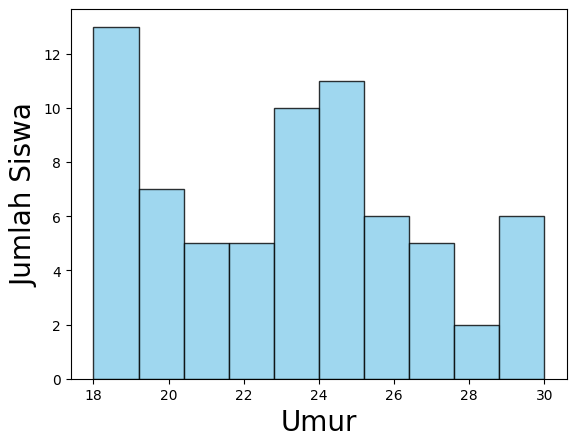

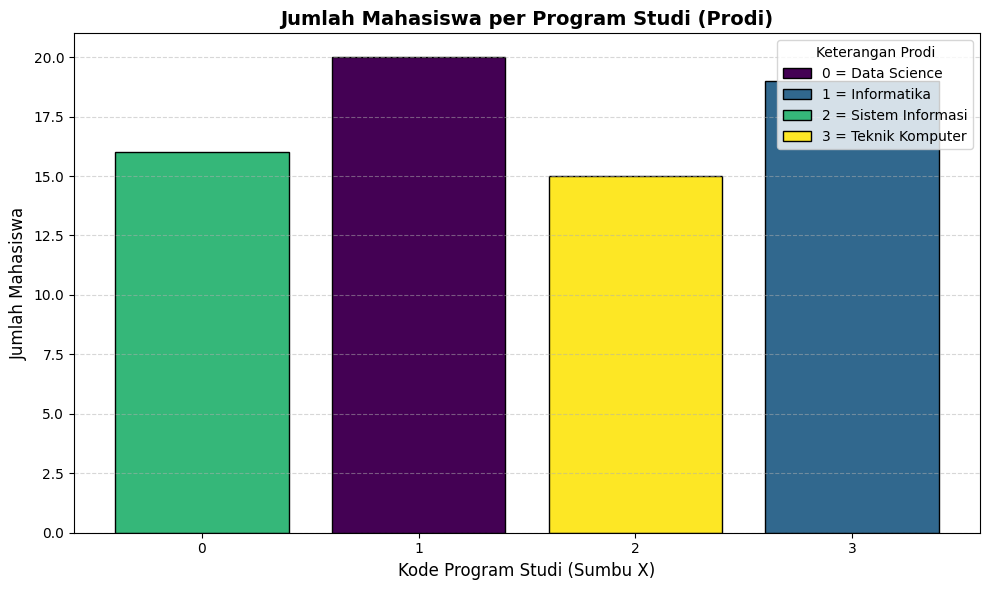

In [48]:

plt.hist(df['Umur'], bins=10, color='skyblue', edgecolor='black', alpha=0.8)
plt.xlabel('Umur', fontsize=20)
plt.ylabel('Jumlah Siswa', fontsize=20)
plt.figure(figsize=(10, 6))
prodi_counts = df['Prodi'].value_counts()
x_axis = prodi_counts.index
y_axis = prodi_counts.values
warna_batang = ['#440154', '#31688e', '#35b779', '#fde725']
bars = plt.bar(x_axis, y_axis, color=warna_batang[:len(x_axis)], edgecolor='black')

plt.title('Jumlah Mahasiswa per Program Studi (Prodi)', fontsize=14, fontweight='bold')
plt.xlabel('Kode Program Studi', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)

plt.xticks(x_axis)
labels_keterangan = [
    '0 = Data Science',
    '1 = Informatika',
    '2 = Sistem Informasi',
    '3 = Teknik Komputer'
]

plt.legend(handles=bars, labels=labels_keterangan, title="Keterangan Prodi", loc="upper right")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
